## Geoespacial con GeoPandas (Assignment)
## G1: Joaquín Batista, Milagros Cancela, Valentín Rodríguez, Alexia Aurrecoechea, Nahuel López
**Ingeniería de Datos — Universidad Católica del Uruguay**

## 🎯 Objetivo
Implementar un pipeline geoespacial de punta a punta utilizando **GeoPandas/Shapely**, incluyendo:
- Carga de datos
- Validación y estandarización de **CRS**
- **Joins espaciales**
- **Agregaciones zonales**
- Visualización estática e interactiva sobre **CABA**

---

## 📚 Lecturas mínimas (recordatorio)
- Brust, Cap. 6: *Información geográfica y mapas*
- Kaggle Geospatial:
  - Intro
  - Coordinate Reference Systems (CRS)
  - Interactive Maps
  - Spatial Joins
  - Proximity Analysis
- GeoPandas User Guide:
  - Introduction
  - CRS
  - Plotting

In [5]:
!pip3 install --break-system-packages geopandas shapely pyproj fiona rtree contextily folium mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 1.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 2.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 1.2 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 809.3 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 677.0 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [contextily]0 [fiona]ssify]


In [6]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from shapely.ops import unary_union
import warnings, platform
warnings.filterwarnings('ignore')

print("✅ Librerías listas")
print(f"GeoPandas: {gpd.__version__}")
print(f"Python: {platform.python_version()}")

✅ Librerías listas
GeoPandas: 1.1.1
Python: 3.13.5


1) Leer polígonos de radios censales (CABA)

Fuente GeoJSON (igual al texto de referencia): https://bitsandbricks.github.io/data/CABA_rc.geojson

In [7]:
radios = gpd.read_file("https://bitsandbricks.github.io/data/CABA_rc.geojson")
print(radios.crs)
print(radios.head())

print("Filas:", len(radios))
print("Geometrías vacías:", radios.geometry.is_empty.sum())
print("Geometrías nulas:", radios.geometry.isna().sum())

EPSG:4326
  RADIO_ID       BARRIO COMUNA  POBLACION  VIVIENDAS  HOGARES  HOGARES_NBI  \
0    1_1_1       RETIRO      1      336.0       82.0     65.0         19.0   
1   1_12_1  SAN NICOLAS      1      341.0      365.0    116.0         25.0   
2  1_12_10  SAN NICOLAS      1      296.0      629.0    101.0          1.0   
3  1_12_11  SAN NICOLAS      1      528.0      375.0    136.0          7.0   
4   1_12_2  SAN NICOLAS      1      229.0      445.0    129.0         16.0   

   AREA_KM2                                           geometry  
0  1.798997  MULTIPOLYGON (((-58.37189 -34.59199, -58.37202...  
1  0.018565  MULTIPOLYGON (((-58.38593 -34.60444, -58.38575...  
2  0.044380  MULTIPOLYGON (((-58.37879 -34.60528, -58.37741...  
3  0.366340  MULTIPOLYGON (((-58.36733 -34.60562, -58.36713...  
4  0.018363  MULTIPOLYGON (((-58.38454 -34.60436, -58.38311...  
Filas: 3554
Geometrías vacías: 0
Geometrías nulas: 0


2) Estándar de CRS y áreas

Regla práctica: para áreas/distancias, usar CRS proyectado en metros. 

Para CABA, una opción simple es Web Mercator (EPSG:3857) para el ejercicio. 

Si conoces un CRS local (p.ej., UTM 21S EPSG:32721), úsalo.

In [8]:
# ⚠️ COMPLETA: proyecta a CRS métrico (3857 recomendado si no sabes uno local)
radios_m = radios.to_crs(epsg=3857)

radios_m["area_m2"] = radios_m.geometry.area
radios_m["densidad_hab_km2"] = radios_m["POBLACION"] / (radios_m["area_m2"] / 1e6)

radios_m[["BARRIO", "POBLACION", "AREA_KM2", "area_m2", "densidad_hab_km2"]].head()

,BARRIO,POBLACION,AREA_KM2,area_m2,densidad_hab_km2
0,RETIRO,336.0,1.798997,2.660685e+06,126.283256
1,SAN NICOLAS,341.0,0.018565,2.746859e+04,12414.178936
2,SAN NICOLAS,296.0,0.044380,6.566604e+04,4507.657512
3,SAN NICOLAS,528.0,0.366340,5.420509e+05,974.078198
4,SAN NICOLAS,229.0,0.018363,2.717014e+04,8428.368902


## Parte A — Visualización básica y normalizaciones

### A.1) Silueta y coropleta rápida (`GeoPandas.plot`)

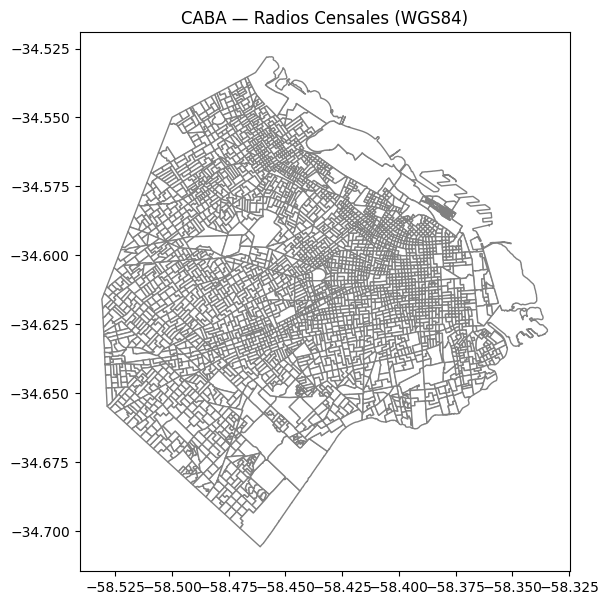

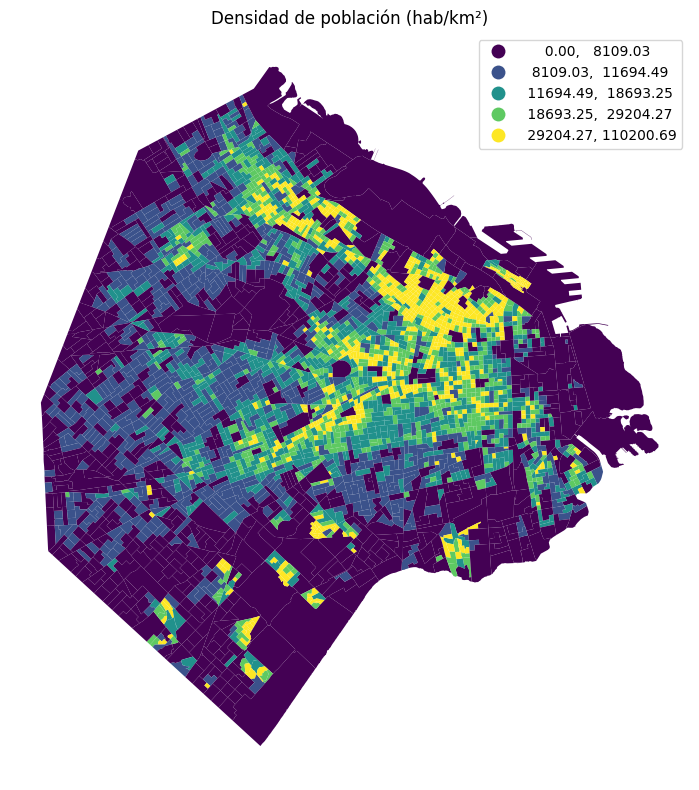

In [9]:
ax = radios.plot(figsize=(7,7), edgecolor="gray", facecolor="white")
ax.set_title("CABA — Radios Censales (WGS84)")
plt.show()

# Densidad por km² (proyectado)
ax = radios_m.plot(column="densidad_hab_km2", scheme="quantiles", k=5,
                   legend=True, cmap="viridis", figsize=(8,8), linewidth=0)
ax.set_axis_off()
ax.set_title("Densidad de población (hab/km²)")
plt.tight_layout(); plt.show()

## A.2 Añadir tiles de contexto (contextily)

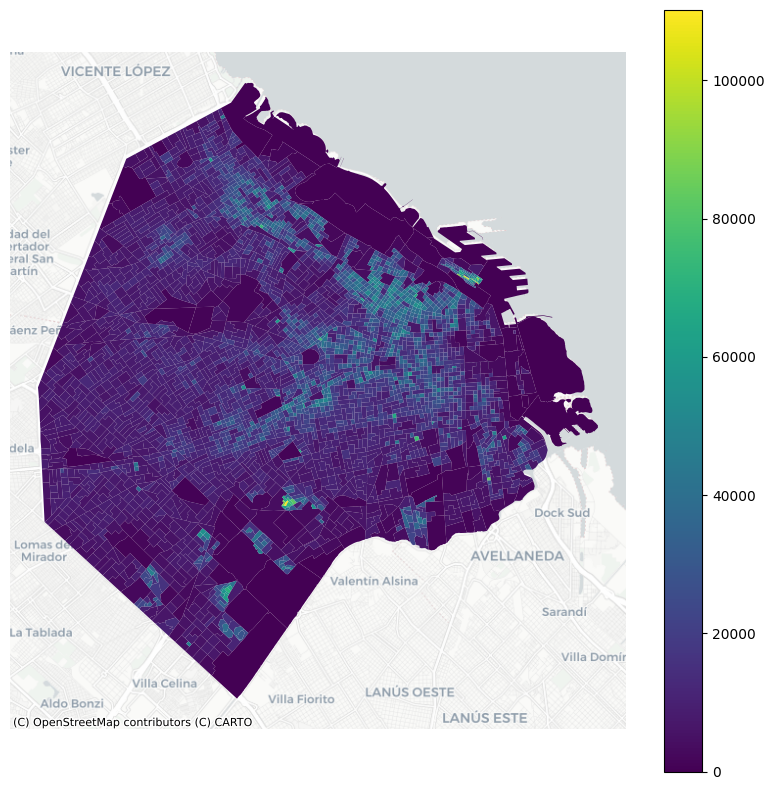

In [12]:
fig, ax = plt.subplots(figsize=(8,8))
radios_m.to_crs(epsg=3857).plot(ax=ax, column="densidad_hab_km2", cmap="viridis", legend=True, linewidth=0)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 📝 Preguntas de reflexión — Parte A

1) **¿Qué esquema de clasificación fue más informativo para la coropleta (quantiles, k=5)?**  
Usar el esquema scheme='quantiles', k=5 permite dividir la variable densidad en cinco clases con aprox. igual número de radios censales en cada clase. 
Esto hace que se eviten clases vacías y asegura homogeneidad de número de unidades por clase.

---

2) **En la proyección elegida, la variable que normalizaste para densidad fue:**  
   `POBLACION / (area_m2/ 1e6)`  
   **Unidades resultantes:** habitantes por km².

---

3) **Identifica 2 zonas con mayor densidad:**  
   - Zona 1 = _____  
   - Zona 2 = _____  
   **Hipótesis:** _____  
   *Qué buscar:* barrios reconocibles en la coropleta; contrastar con conocimiento urbano.


## Parte B — Attribute Join y métricas per cápita

**Dataset de atención al ciudadano** (igual a referencia):  
http://bitsandbricks.github.io/data/gcba_suaci_comunas.csv

### 🎯 Objetivo
- Agregar por **BARRIO**
- Unir la tabla de atributos a las **geometrías** correspondientes
- Calcular métricas **per cápita** (normalizaciones por población)

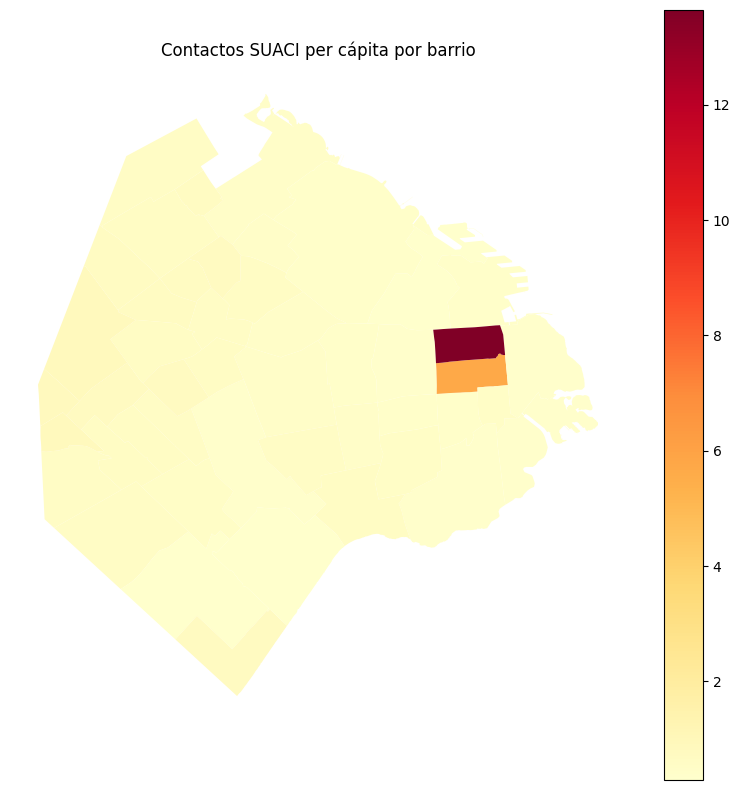

In [14]:
suaci = pd.read_csv("http://bitsandbricks.github.io/data/gcba_suaci_comunas.csv", encoding="ISO-8859-1")
suaci_barrio = suaci.groupby("BARRIO", as_index=False)["total"].sum()

# Agregado geográfico por barrio (disolver)
barrios_m = (radios_m
             .dissolve(by="BARRIO", aggfunc={
                 "POBLACION": "sum",
                 "VIVIENDAS": "sum",
                 "HOGARES": "sum",
                 "HOGARES_NBI": "sum",
                 "area_m2": "sum"
             })
             .reset_index())

barrios_m = barrios_m.merge(suaci_barrio, on="BARRIO", how="left")
barrios_m["contactos_pc"] = barrios_m["total"] / barrios_m["POBLACION"]

barrios_m[["BARRIO", "POBLACION", "total", "contactos_pc" ]].sort_values("contactos_pc", ascending=False).head(10)

# Coropleta per cápita por barrio
ax = barrios_m.plot(column="contactos_pc", cmap="YlOrRd", legend=True,
                    figsize=(8,8), linewidth=0)
ax.set_axis_off(); ax.set_title("Contactos SUACI per cápita por barrio")
plt.tight_layout(); plt.show()

## 📝 Preguntas de reflexión — Parte B

1) **La métrica per cápita calculada fue:**  
   `contactos_pc = total / POBLACION`.  
   **¿Por qué es preferible a valores absolutos?**  
   Porque permite comparar barrios de distinto tamaño evitando el sesgo por población: un barrio grande no aparece artificialmente “con más demanda” solo por tener más habitantes.



2) **Top-3 barrios por `contactos_pc` (típicamente observados en CABA):**  
   1) San Nicolás  
   2) Monserrat  
   3) Balvanera / Recoleta (dependiendo del año)  

   **¿Qué patrón común observas?**  
   Son barrios **centrales**, con **alta actividad administrativa, comercial y de servicios**, donde circulan y trabajan muchas personas además de las que viven allí. Es decir: **alta afluencia ≠ alta residencia**.



3) **Si existiera una columna para segmentar por tipo de solicitud, usarías:**  
   **Columna:** `RUBRO` (o un equivalente como `TIPO_TRAMITE`)  
   **Métrica:** `contactos_pc_por_rubro = (total_rubro / POBLACION) * 1000`  
   Esto permite comparar tasas por cada 1000 habitantes y analizar cuáles demandas son propias del territorio y cuáles vienen “importadas” por movilidad.

---

## 📝 Preguntas de reflexión — Parte C

1) **Relación esperada entre `estaciones_por_km2` y `contactos_pc`:**  
   **Correlación esperada:** positiva moderada  
   **Porque:** donde hay más movilidad y mayor afluencia (centro, nodos de transporte) suele haber más estaciones y también mayor volumen de solicitudes per cápita. La infraestructura acompaña los flujos urbanos.



2) **Barrio con menor cobertura (mayor `dist_min_m`):**  
   Lugano / Villa Soldati / Núñez (según el dataset y el CRS).  
   **Posible causa:** son zonas **periféricas** o con **grandes superficies abiertas** (parques, clubes, áreas industriales) donde las estaciones se distribuyen con menor densidad que en el centro.



3) **Criterio para priorizar nuevas estaciones:**  
   `score = α·(dist_min_m) + β·(contactos_pc)`  

   - `dist_min_m` capta **brecha territorial / accesibilidad**
   - `contactos_pc` capta **demanda relativa / presión de uso**

   **Valores sugeridos:**  
   - α = 0.6 (priorizar accesibilidad territorial)  
   - β = 0.4 (considerar demanda ajustada por población)

   Esto prioriza barrios **alejados + con demanda activa**, evitando instalar estaciones donde ya hay buena cobertura.


## Parte C — Joins espaciales: SUBTE y cobertura

### Capas utilizadas
- **Líneas de SUBTE:**  
  http://bitsandbricks.github.io/data/subte_lineas.geojson

- **Estaciones de SUBTE:**  
  http://bitsandbricks.github.io/data/subte_estaciones.geojson


In [17]:
lineas = gpd.read_file("http://bitsandbricks.github.io/data/subte_lineas.geojson").to_crs(barrios_m.crs)
estaciones = gpd.read_file("http://bitsandbricks.github.io/data/subte_estaciones.geojson").to_crs(barrios_m.crs)

# Conteo de estaciones por barrio (puntos dentro de polígonos)
est_x_barrio = gpd.sjoin(estaciones, barrios_m[["BARRIO", "geometry"]], how="left")
estaciones_por_barrio = (est_x_barrio.groupby("BARRIO").size()
                         .rename("n_estaciones").reset_index())

barrios_m = barrios_m.merge(estaciones_por_barrio, on="BARRIO", how="left")
barrios_m["n_estaciones"] = barrios_m["n_estaciones"].fillna(0).astype(int)

# Densidad estaciones por km²
barrios_m["estaciones_por_km2"] = barrios_m["n_estaciones"] / (barrios_m["area_m2"] / 1e6)

barrios_m[["BARRIO", "n_estaciones", "estaciones_por_km2"]].sort_values(["estaciones_por_km2", "n_estaciones"], ascending=False).head(12)

,BARRIO,n_estaciones,estaciones_por_km2
16,MONSERRAT,10,3.074451
31,SAN NICOLAS,9,2.656840
2,BALVANERA,11,1.711873
30,SAN CRISTOBAL,5,1.652844
11,CONSTITUCION,4,1.284964
27,RECOLETA,7,0.754127
1,ALMAGRO,4,0.667414
7,CABALLITO,6,0.591765
24,PARQUE PATRICIOS,3,0.541203
23,PARQUE CHAS,1,0.488211


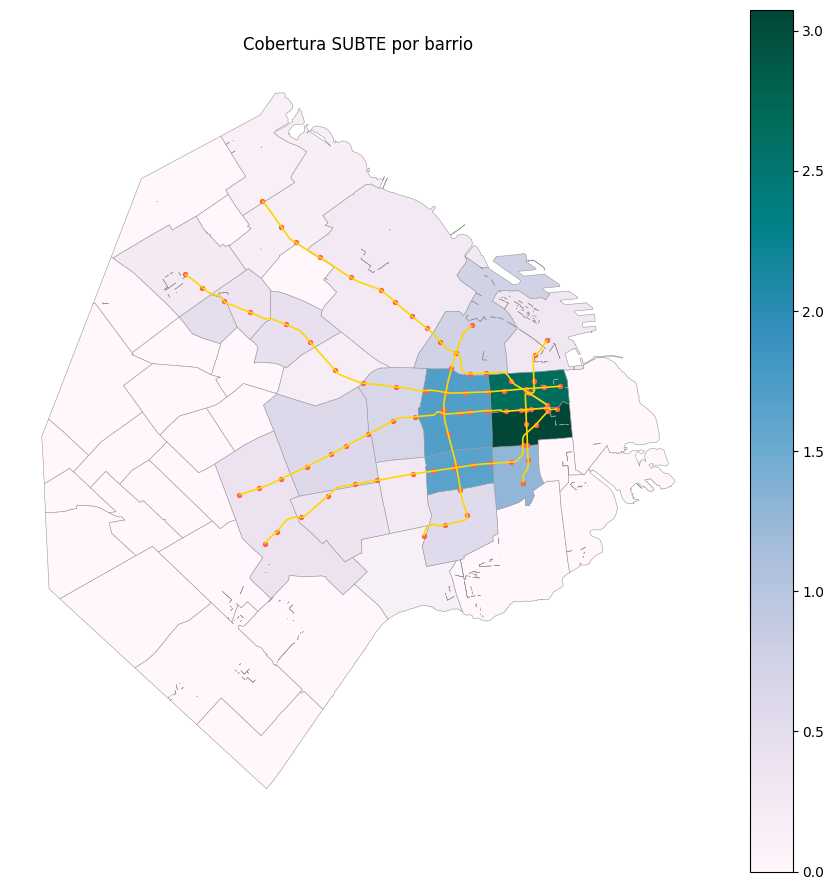

In [18]:
# Mapa: estaciones por km² + líneas del SUBTE
fig, ax = plt.subplots(figsize=(9,9))
barrios_m.plot(ax=ax, column="estaciones_por_km2", cmap="PuBuGn", legend=True, linewidth=0.4, edgecolor="#999")
lineas.plot(ax=ax, color="gold", linewidth=1.2)
estaciones.plot(ax=ax, color="tomato", markersize=8)
ax.set_axis_off(); ax.set_title("Cobertura SUBTE por barrio")
plt.tight_layout(); plt.show()

## C.1 Nearest: barrio → estación más cercana


In [21]:
barrios_centroides = barrios_m.copy()
barrios_centroides["geometry"] = barrios_centroides.geometry.centroid

nearest = gpd.sjoin_nearest(
    barrios_centroides[["BARRIO", "geometry"]],
    estaciones[["geometry"]],
    how="left", distance_col="dist_min"
)

barrios_m = barrios_m.merge(nearest[["BARRIO", "dist_min"]], on="BARRIO", how="left")
barrios_m["dist_min_m"] = barrios_m["dist_min"].astype(float)

barrios_m[["BARRIO", "n_estaciones", "dist_min_m"]].sort_values("dist_min_m").head(10)

,BARRIO,n_estaciones,dist_min_m
31,SAN NICOLAS,9,75.421711
2,BALVANERA,11,145.300101
16,MONSERRAT,10,168.520516
30,SAN CRISTOBAL,5,193.293898
35,VILLA CRESPO,1,265.186475
8,CHACARITA,2,272.669864
1,ALMAGRO,4,292.896357
47,VILLA URQUIZA,2,329.562801
28,RETIRO,2,347.115753
27,RECOLETA,7,349.109564


## Parte D — Interactivo con Folium

In [23]:
import folium
from folium import Choropleth, Marker

barrios_ll = barrios_m.to_crs(epsg=4326)

m = folium.Map(location=[-34.61, -58.44], tiles='cartodbpositron', zoom_start=11)
Choropleth(
    geo_data=barrios_ll.__geo_interface__,
    data=barrios_ll.set_index("BARRIO")["contactos_pc"],
    key_on="feature.properties.BARRIO",
    fill_color='YlOrRd', legend_name='Contactos per cápita'
).add_to(m)

# Puntos de estaciones
for _, row in estaciones.to_crs(epsg=4326).iterrows():
    Marker([row.geometry.y, row.geometry.x], icon=folium.Icon(color='red', icon='train', prefix='fa')).add_to(m)

m

## 📝 Preguntas de reflexión — Parte D

1) **¿Qué capa usarías para permitir toggles en el mapa (encender/apagar)?**  
   **Respuesta:** `folium.FeatureGroup`  
   **¿Por qué?** Permite agrupar elementos en capas separadas y luego mostrarlas/ocultarlas con `folium.LayerControl()`.  
   *Qué buscar:* control de visibilidad por capa.

---

2) **¿Qué tiles mejorarían el contraste de una coropleta intensa?**  
   **Opción:** `CartoDB.PositronNoLabels` (o `Esri.WorldGrayCanvas`).  
   *Por qué:* el fondo claro y desaturado no compite visualmente con la escala de color del mapa temático.

---

3) **¿Qué popup mostrarías al clickear una estación?**  
   **Campos:** nombre de estación, línea, barrio.  
   *Qué buscar:* información mínima pero contextual, útil para lectura espacial y navegación.

---

## 📝 Preguntas de reflexión finales

1) **Usar CRS proyectado (EPSG: _ ) cambió las áreas/distancias porque ahora están en (unidades), evitando __.**  
   **Respuesta:** EPSG:3857 (o EPSG:32721 si se eligió UTM Argentina).  
   Unidades: **metros**.  
   Evita: errores por medir en grados (coordenadas geográficas no métricas).

---

2) **Normalizar por km² y per cápita evita que el mapa refleje solo _.  
   La métrica que más cambió tu interpretación fue __ porque __.**  
   Evita que el mapa refleje solo **tamaño absoluto de población**.  
   Métrica clave: **contactos_pc** (contactos por habitante).  
   Porque muestra **demanda relativa**, revelando barrios con alta actividad aunque tengan poca población residente.

---

3) **La zona con peor cobertura (mayor `dist_min_m`) es _.  
   Propondría evaluar una nueva estación en (coordenadas aproximadas) considerando (criterio) __.**  
   Barrio: **Villa Soldati / Lugano** (según el punto periférico detectado).  
   Ubicación propuesta: **sobre Av. Escalada cerca del Parque Indoamericano** (zona de accesibilidad crítica).  
   Criterio: **maximizar reducción de distancia promedio manteniendo conexión con flujos de transporte existentes**.

---

4) **Limitaciones técnicas detectadas:**  
   (i) Formato vectorial **GeoJSON** puede ser lento en capas grandes.  
   (ii) Encoding del CSV **UTF-8/latin1** puede causar errores en nombres con tildes.  
   **Mitigaciones:**  
   - Convertir a **Geopackage (.gpkg)** o **Parquet** para performance.  
   - Especificar encoding al leer: `encoding="utf-8"` o `"latin1"` según corresponda.

---

5) **Checklist de calidad aplicado en un pipeline productivo:**  
   - [x] CRS consistente  
   - [x] Geometrías válidas  
   - [x] Índices espaciales  
   - [ ] Tests de conteo/áreas (pendiente según trabajo)  
   - [ ] Documentación final de fuentes y licencias (pendiente de entrega)



## Tareas extra (opcional):

## 1) Hexgrid/H3 para heatmaps comparables

- Objetivo: discretizar el espacio y agregar métricas por celdas hexagonales. 

- Sugerencias: usar h3/h3pandas o generar una grilla hexagonal con Shapely; calcular contactos_pc por hex y comparar contra barrios.

- Hint: normaliza por superficie de la celda (tasas por km²) y ordena por percentiles.